In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import tensorflow as tf
from tensorflow import keras
import pandas as pd

import sys
sys.path.append("..")
import LJ_lmft_utils as lmft

# Enable or disable Tensor Float 32 Execution
tf.config.experimental.enable_tensor_float_32_execution(False)

2025-03-22 13:04:34.993523: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-22 13:04:34.994135: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-22 13:04:34.996886: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-22 13:04:35.003847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742648675.015075   23163 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742648675.01

In [2]:
class BulkCorrelationEvaluator:
    """
    This class provides utilities to calculate c2 of the bulk fluid.
    """
    def __init__(self, model, rho_bulk, T, dx=0.005, inputbins=1201):
        self.model = model
        self.dx = dx
        self.rho_bulk = rho_bulk
        self.inputBins = inputbins

        rhoWindow = np.full(self.inputBins, self.rho_bulk)
        inputBinsHalf = self.inputBins // 2
        self.xWindow = self.dx * np.linspace(-inputBinsHalf, inputBinsHalf, self.inputBins)
        inputWindow = rhoWindow.reshape(1, self.inputBins, 1)
        self.inputWindow = tf.Variable(inputWindow)

        self.T = tf.Variable(T)
        self.T = tf.reshape(self.T, [1, -1])

    def c2(self):
        with tf.GradientTape(persistent=True, watch_accessed_variables=False) as tape:
            tape.watch(self.inputWindow)
            c1_result = self.model([self.inputWindow, self.T])
        c2_result = tf.squeeze(tape.gradient(c1_result, self.inputWindow)).numpy() / self.dx

        return c2_result
    
    def c1(self):
        with tf.GradientTape(persistent=True, watch_accessed_variables=False) as tape:
            tape.watch(self.inputWindow)
            c1_result = self.model([self.inputWindow, self.T])
        
        return c1_result.numpy().flatten()
    

def get_c2r(c2, z):
    deriv_c2 = np.gradient(c2, z)
    r = z
    return r, - deriv_c2 / (2 * np.pi * r)

def Hankel_transform(c2, r, k):
    return np.trapz(c2 * r * np.sin(k * r), r) * 4 * np.pi / k

def get_c2k(c2, r):
    k = np.linspace(0.001, 100, len(r))
    c2k = np.array([Hankel_transform(c2, r, k_) for k_ in k])
    return k, c2k

## Load Data and Plot

In [3]:
T = 1.5
L = 10
rho_bulk = [0.2, 0.4, 0.6, 0.8]

In [8]:
sim_lj = pd.read_csv("../../data/simulation/sk_lj.dat", sep=" ", header=None, skiprows=1)
sim_wca = pd.read_csv("../../data/simulation/sk_wca.dat", sep=" ", header=None, skiprows=1)

/tmp/ipykernel_23163/1486862193.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(c2 * r * np.sin(k * r), r) * 4 * np.pi / k


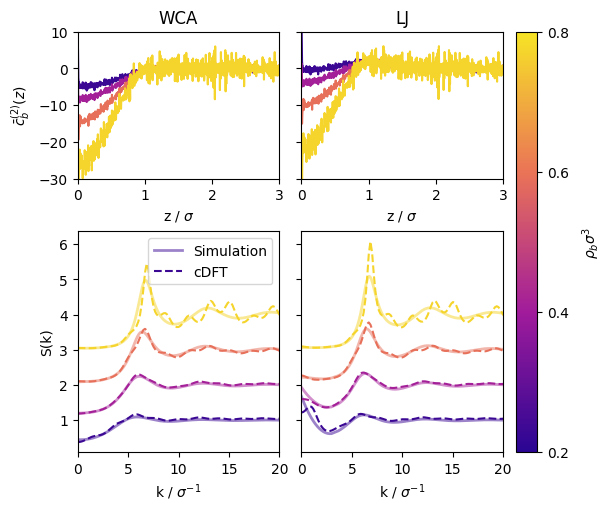

In [ ]:

model = keras.models.load_model("../../models/WCA.keras")

fig, ax = plt.subplots(2, 2, figsize=(6, 5), height_ratios=[1, 1.5], layout="compressed", sharex="row", sharey="row")

orig_cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=min(rho_bulk), vmax=max(rho_bulk))
colors = orig_cmap(np.linspace(0.05, 0.95, len(rho_bulk)))
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors)
plot_colour = cmap(np.linspace(0.05, 0.95, len(rho_bulk)))

for i in range(len(rho_bulk)):

    ### Plot WCA
    bulkcorr = BulkCorrelationEvaluator(model, rho_bulk[i], T)
    c2 = bulkcorr.c2()
    z = bulkcorr.xWindow

    c2 = c2[z>0]
    z = z[z>0]
    r, c2_r = get_c2r(c2, z)
    k, c2_k = get_c2k(c2_r, r)
    h_k = c2_k/(1 - rho_bulk[i]*c2_k)
    Sk = 1 + rho_bulk[i]*h_k
    
    ax[0, 0].plot(z, c2, color=plot_colour[i])

    ax[1, 0].plot(sim_wca[0], sim_wca[i+1]+i, color=plot_colour[i], alpha=0.5, lw=2, label="Simulation" if i==0 else "")
    ax[1, 0].plot(k, Sk+i, color=plot_colour[i], label="cDFT" if i==0 else "", linestyle="dashed")
    

    ### Plot LJ
    bulkcorr = BulkCorrelationEvaluator(model, rho_bulk[i], T)
    c2 = bulkcorr.c2()
    z = bulkcorr.xWindow

    att = lmft.attract(z, 1, 1, 2.5)[len(z):-len(z)]
    
    c2 = c2[z>0] - att[z>0]/T
    z = z[z>0]
    r, c2_r = get_c2r(c2, z)
    k, c2_k = get_c2k(c2_r, r)

    h_k = c2_k/(1 - rho_bulk[i]*c2_k)
    Sk = 1 + rho_bulk[i]*h_k

    ax[0,1].plot(z, c2, color=plot_colour[i])

    ax[1, 1].plot(sim_lj[0], sim_lj[i+1]+i, color=plot_colour[i], alpha=0.5, lw=2)
    ax[1, 1].plot(k, Sk+i, color=plot_colour[i], linestyle="dashed")



ax[0, 0].set_xlim(0, 3)
ax[0, 0].set_ylim(-30, 10)
ax[0, 0].set_ylabel("$\\bar c^{(2)}_{b}(z)$")
ax[0, 0].set_xlabel("z / $\\sigma$")
ax[0,1].set_xlabel("z / $\\sigma$")

ax[1,0].set_xlim(0, 20)
ax[1,0].set_ylabel("S(k)")
    
ax[1,0].legend()
ax[0, 0].set_title("WCA")
ax[0,1].set_title("LJ")

ax[1, 1].set_xlabel("k / $\\sigma^{-1}$")
ax[1, 0].set_xlabel("k / $\\sigma^{-1}$")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, location="right", pad=0.01)
cbar.set_label('$\\rho_b \\sigma^3 $', labelpad=8)
cbar.set_ticks(ticks=rho_bulk)

#plt.savefig("../structure_factor.png", bbox_inches="tight",dpi=600, pad_inches=0.01)
plt.show()